In [29]:
import pandas as pd

print("Working!")

Working!


In [30]:
import pandas as pd

# Load subcounty data
subcounty_df = pd.read_csv("DATA/TABLES/Uganda_Karamoja_Subcounty_Crop_Yield_Population.csv")

# Load district data
district_df = pd.read_csv("DATA/TABLES/Uganda_Karamoja_District_Crop_Yield_Population.csv")

# Preview
subcounty_df.head()

,OBJECTID,SUBCOUNTY_NAME,DISTRICT_NAME,POP,Area,Karamoja,S_Yield_Ha,M_Yield_Ha,Crop_Area_Ha,S_Area_Ha,M_Area_Ha,S_Prod_Tot,M_Prod_Tot
0,263,KACHERI,KOTIDO,17244,1067176155,Y,354.207411,1137.467019,7023.533691,6434.342449,528.124229,2.279092e+06,600723.892900
1,264,KOTIDO,KOTIDO,52771,597575188,Y,367.890523,1162.996687,13587.990760,12455.592640,824.767081,4.582294e+06,959201.382500
2,265,KOTIDO TOWN COUNCIL,KOTIDO,27389,23972401,Y,369.314177,1167.005832,1656.531855,1520.322052,8.561644,5.614765e+05,9991.488268
3,266,NAKAPERIMORU,KOTIDO,38775,419111591,Y,283.324569,852.366578,7087.823334,6761.488901,45.721712,1.915696e+06,38971.659080
4,267,PANYANGARA,KOTIDO,65704,880955930,Y,373.836926,1283.859882,10398.249390,10111.198130,172.611914,3.779939e+06,221609.511400


# Karamoja Food Security Analysis

## Business Understanding
Karamoja is one of the most food-insecure regions in Uganda. NGOs need better insights to prioritize interventions.

This project aims to analyze crop yield (maize and sorghum) and population data to support decision-making.

## Objectives
- Identify high and low productivity areas
- Compare maize vs sorghum performance
- Understand population pressure vs food production

### Data understanding

## Data Understanding

In this section i explore the structure, content, and quality of the dataset.  
This helps us understand key variables, detect missing values, and identify patterns.

### Dataset Size

I check the number of rows and columns in both datasets.

In [31]:
# Check shape (rows, columns)
subcounty_df.shape

(52, 13)

In [32]:
district_df.shape

(7, 11)

In [33]:
# Column names
subcounty_df.columns

Index(['OBJECTID', 'SUBCOUNTY_NAME', 'DISTRICT_NAME', 'POP', 'Area',
       'Karamoja', 'S_Yield_Ha', 'M_Yield_Ha', 'Crop_Area_Ha', 'S_Area_Ha',
       'M_Area_Ha', 'S_Prod_Tot', 'M_Prod_Tot'],
      dtype='object')

### Data Types and Missing Values

I inspect the data types of each column and check for missing values.

In [34]:
# Data types and missing values
subcounty_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   OBJECTID        52 non-null     int64  
 1   SUBCOUNTY_NAME  52 non-null     object 
 2   DISTRICT_NAME   52 non-null     object 
 3   POP             52 non-null     int64  
 4   Area            52 non-null     int64  
 5   Karamoja        52 non-null     object 
 6   S_Yield_Ha      52 non-null     float64
 7   M_Yield_Ha      52 non-null     float64
 8   Crop_Area_Ha    52 non-null     float64
 9   S_Area_Ha       52 non-null     float64
 10  M_Area_Ha       52 non-null     float64
 11  S_Prod_Tot      52 non-null     float64
 12  M_Prod_Tot      52 non-null     float64
dtypes: float64(7), int64(3), object(3)
memory usage: 5.4+ KB


### Summary Statistics

I compute summary statistics to understand the distribution of numerical variables such as population and crop yields.

In [35]:
# Summary statistics
subcounty_df.describe()

,OBJECTID,POP,Area,S_Yield_Ha,M_Yield_Ha,Crop_Area_Ha,S_Area_Ha,M_Area_Ha,S_Prod_Tot,M_Prod_Tot
count,52.000000,52.000000,5.200000e+01,52.000000,52.000000,52.000000,52.000000,52.000000,5.200000e+01,5.200000e+01
mean,787.865385,28934.692308,5.331913e+08,274.165405,940.259552,2839.646974,2253.143395,536.300569,6.557443e+05,5.500730e+05
std,280.101314,20865.122974,4.913308e+08,118.569907,321.641901,3110.505917,2954.355858,724.092288,9.915839e+05,7.939707e+05
min,263.000000,1418.000000,2.121209e+06,108.156411,0.000000,0.171390,0.130941,0.000000,1.728126e+01,0.000000e+00
25%,597.750000,16558.500000,1.568923e+08,173.034066,743.075879,964.876031,405.394759,79.821743,1.210555e+05,6.087012e+04
50%,810.500000,23053.500000,3.848356e+08,277.255206,1016.684002,1654.265138,1231.824456,326.479336,2.543687e+05,2.896239e+05
75%,982.250000,39461.000000,7.749029e+08,368.246437,1203.548665,3267.564651,2429.985069,740.296675,6.040942e+05,8.114574e+05
max,1320.000000,100919.000000,2.069555e+09,560.313070,1396.991494,13587.990760,12964.499730,3840.698081,4.582294e+06,4.365058e+06


In [36]:
subcounty_df.isnull().sum()
district_df.isnull().sum()

OBJECTID        0
NAME            0
POP             0
Area            0
S_Yield_Ha      0
M_Yield_Ha      0
Crop_Area_Ha    0
S_Area_Ha       0
M_Area_Ha       0
S_Prod_Tot      0
M_Prod_Tot      0
dtype: int64

In [37]:
subcounty_df['DISTRICT_NAME'].unique()
subcounty_df['Karamoja'].value_counts()

Karamoja
Y    52
Name: count, dtype: int64

In [38]:
# How many districts?
subcounty_df['DISTRICT_NAME'].nunique()

# Total population
subcounty_df['POP'].sum()

# Average yield
subcounty_df[['S_Yield_Ha', 'M_Yield_Ha']].mean()

S_Yield_Ha    274.165405
M_Yield_Ha    940.259552
dtype: float64

In [39]:
district_df.head()
district_df.describe()

,OBJECTID,POP,Area,S_Yield_Ha,M_Yield_Ha,Crop_Area_Ha,S_Area_Ha,M_Area_Ha,S_Prod_Tot,M_Prod_Tot
count,7.000000,7.000000,7.000000e+00,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000e+00,7.000000e+00
mean,61.714286,214943.571429,3.960853e+09,269.285714,986.142857,21094.520379,16737.636651,3983.947082,4.873098e+06,4.085632e+06
std,36.481567,188604.280916,1.781860e+09,119.243049,321.566700,17363.854165,16625.963460,2678.911441,5.743724e+06,2.877188e+06
min,5.000000,90385.000000,1.643583e+09,128.000000,355.000000,5470.068394,2973.423860,1190.050606,6.069440e+05,4.224680e+05
25%,37.000000,114800.500000,3.171069e+09,171.000000,899.500000,5860.128883,4009.522373,1799.997070,1.040529e+06,1.966571e+06
50%,80.000000,146780.000000,3.641540e+09,279.000000,1040.000000,22944.296020,16142.015880,2733.661014,2.211456e+06,3.545558e+06
75%,88.500000,205391.000000,4.362553e+09,343.500000,1206.000000,27247.185510,19890.764085,6484.753740,6.290160e+06,6.288030e+06
max,96.000000,627057.000000,7.373606e+09,449.000000,1297.000000,53032.649450,50247.443900,7394.416334,1.663190e+07,8.122197e+06


### Correlation Analysis

I examine relationships between numerical variables such as:
- Population
- Crop area
- Yield
- Production

This helps identify patterns and dependencies between variables.

In [40]:
# Correlation analysis
correlation_matrix = subcounty_df.corr(numeric_only=True)
correlation_matrix

,OBJECTID,POP,Area,S_Yield_Ha,M_Yield_Ha,Crop_Area_Ha,S_Area_Ha,M_Area_Ha,S_Prod_Tot,M_Prod_Tot
OBJECTID,1.000000,-0.413025,0.153613,-0.224381,-0.284216,-0.407773,-0.455794,0.135549,-0.528434,0.117310
POP,-0.413025,1.000000,0.257082,-0.081385,0.135996,0.392587,0.371068,0.157311,0.342992,0.144350
Area,0.153613,0.257082,1.000000,0.005760,0.131586,0.328405,0.265610,0.307355,0.196369,0.262690
S_Yield_Ha,-0.224381,-0.081385,0.005760,1.000000,0.624494,0.171402,0.110636,0.238892,0.288920,0.335797
M_Yield_Ha,-0.284216,0.135996,0.131586,0.624494,1.000000,0.263790,0.221676,0.200557,0.316694,0.334450
Crop_Area_Ha,-0.407773,0.392587,0.328405,0.171402,0.263790,1.000000,0.970304,0.261783,0.945518,0.282030
S_Area_Ha,-0.455794,0.371068,0.265610,0.110636,0.221676,0.970304,1.000000,0.021327,0.958651,0.049947
M_Area_Ha,0.135549,0.157311,0.307355,0.238892,0.200557,0.261783,0.021327,1.000000,0.076654,0.962444
S_Prod_Tot,-0.528434,0.342992,0.196369,0.288920,0.316694,0.945518,0.958651,0.076654,1.000000,0.127794
M_Prod_Tot,0.117310,0.144350,0.262690,0.335797,0.334450,0.282030,0.049947,0.962444,0.127794,1.000000


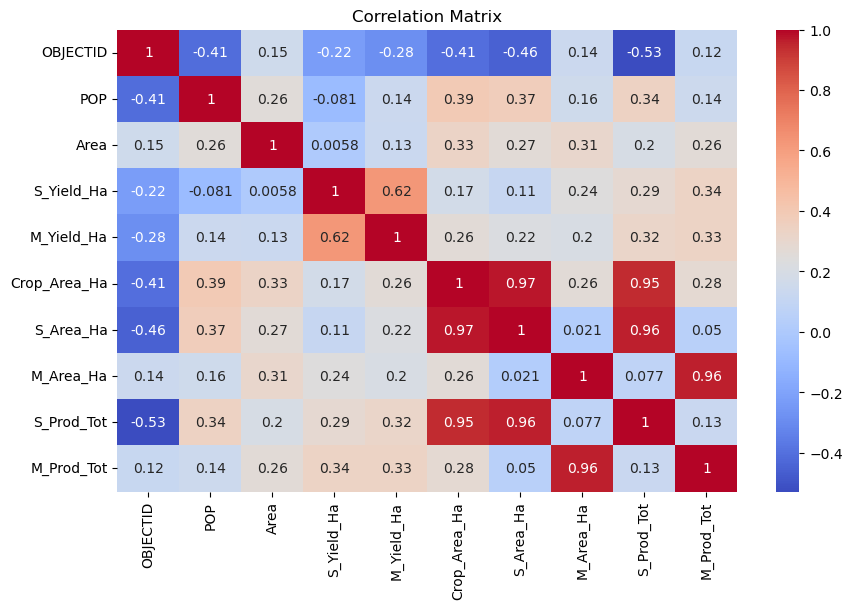

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

### Key Insights from Correlation

- Crop area and production (S_Prod_Tot, M_Prod_Tot) show very strong positive correlation.
- Sorghum and maize yields have a moderate positive relationship.
- Population has a weak correlation with crop yield but a moderate relationship with crop area.
- Larger cultivated areas tend to result in higher total production.

These relationships help identify key drivers of food production in Karamoja.

### Exploratory Data Analysis (EDA)

This section explores key patterns in crop production, yield, and population distribution across districts and subcounties in Karamoja.

### Total Crop Production by District

This analysis aggregates total sorghum and maize production across all subcounties within each district. It helps identify which districts contribute the most to overall food production in the Karamoja region.

In [42]:
# Total production by district
district_production = subcounty_df.groupby('DISTRICT_NAME')[['S_Prod_Tot', 'M_Prod_Tot']].sum()
district_production.sort_values(by='S_Prod_Tot', ascending=False)

,S_Prod_Tot,M_Prod_Tot
DISTRICT_NAME,,
KOTIDO,1.663429e+07,2.010179e+06
NAKAPIRIPIRIT,6.841727e+06,8.125156e+06
KAABONG,5.723091e+06,6.990362e+06
NAPAK,2.209032e+06,5.587379e+06
ABIM,1.472671e+06,1.922133e+06
AMUDAT,6.103003e+05,3.546469e+06
MOROTO,6.075967e+05,4.221161e+05


### Key Insights

- Kotido has the highest sorghum production, significantly outperforming other districts.
- Nakapiripirit and Kaabong show strong maize production compared to other districts.
- Moroto has the lowest production for both sorghum and maize, indicating low agricultural output.
- There is variation across districts, suggesting differences in agricultural capacity or environmental conditions.

This helps identify high-performing and low-performing regions, which is critical for targeted agricultural interventions.

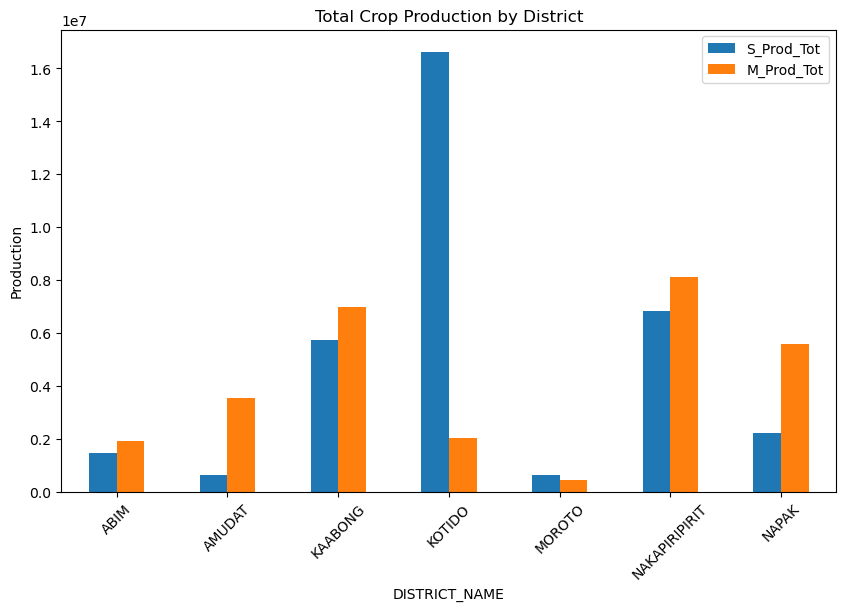

In [43]:
import matplotlib.pyplot as plt

district_production.plot(kind='bar', figsize=(10,6))
plt.title('Total Crop Production by District')
plt.ylabel('Production')
plt.xticks(rotation=45)
plt.show()

### Insights from Crop Production by District

The bar chart shows clear differences in crop production across districts:

- Kotido stands out with extremely high sorghum production, but relatively low maize production, indicating specialization in sorghum farming.
- Nakapiripirit and Kaabong demonstrate strong production in both crops, making them key agricultural contributors.
- Napak and Amudat produce more maize than sorghum, suggesting crop preference or environmental suitability for maize.
- Moroto has the lowest production levels for both crops, indicating potential food insecurity or limited agricultural productivity.

Overall, crop production varies significantly across districts, highlighting regional differences in agricultural performance and possible resource distribution.

In [44]:
# Total production overall
subcounty_df[['S_Prod_Tot', 'M_Prod_Tot']].sum()

S_Prod_Tot    3.409870e+07
M_Prod_Tot    2.860379e+07
dtype: float64

### Overall Crop Production

The total production of sorghum and maize was calculated to determine which crop contributes more to overall food production in the Karamoja region.

The results show that sorghum has a higher total production compared to maize. This suggests that sorghum is the dominant crop in the region, likely due to its better adaptability to the semi-arid climate conditions of Karamoja.

This indicates that sorghum plays a crucial role in food security within the region.

### Average Crop Yield

To evaluate productivity, the average yield per hectare for both sorghum and maize was calculated.

This helps assess which crop is more efficient in terms of output relative to land use.

In [45]:
subcounty_df[['S_Yield_Ha', 'M_Yield_Ha']].mean()

S_Yield_Ha    274.165405
M_Yield_Ha    940.259552
dtype: float64

### Overall Crop Yield Comparison

The average yield per hectare for both sorghum and maize was calculated to assess crop productivity.

The results show that maize has a significantly higher average yield per hectare compared to sorghum. This indicates that maize is more productive in terms of output per unit of land.

This suggests that while sorghum may dominate in total production, maize is more efficient and could potentially produce more output if cultivated under suitable conditions.

In [46]:
yield_by_district = subcounty_df.groupby('DISTRICT_NAME')[['S_Yield_Ha', 'M_Yield_Ha']].mean()
yield_by_district

,S_Yield_Ha,M_Yield_Ha
DISTRICT_NAME,,
ABIM,430.258392,1041.474982
AMUDAT,194.941682,1180.766412
KAABONG,261.719947,989.327866
KOTIDO,336.626575,1108.479354
MOROTO,160.264712,381.708170
NAKAPIRIPIRIT,379.872822,1169.092190
NAPAK,151.359305,722.141048


### Yield Distribution by District

To further understand productivity patterns, average yields were analyzed across different districts.

The results show variation in both sorghum and maize yields across districts. Some districts such as Kotido and Nakapiripirit exhibit relatively higher yields, while others like Moroto and Napak show lower productivity levels.

This variation may be influenced by factors such as soil quality, rainfall distribution, and farming practices. The differences highlight potential areas where agricultural interventions can improve productivity.

<Axes: xlabel='DISTRICT_NAME'>

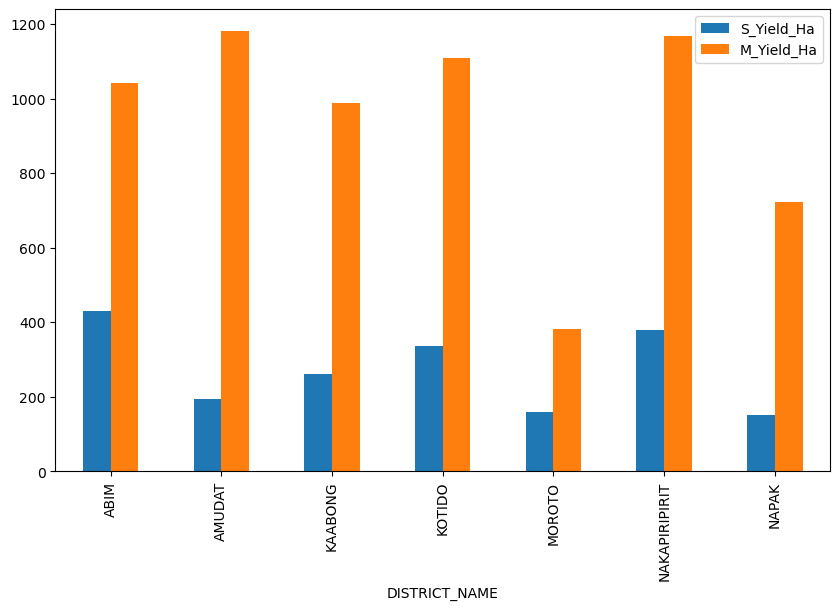

In [47]:
yield_by_district.plot(kind='bar', figsize=(10,6))

### Yield Comparison Across Districts

The bar chart shows the comparison of sorghum and maize yields across different districts in Karamoja.

From the visualization, maize consistently has higher yields than sorghum in all districts. This indicates that maize is more productive per hectare compared to sorghum.

Districts such as Nakapiripirit, Kotido, and Abim show relatively higher yield levels, while districts like Moroto and Napak have lower productivity for both crops.

These differences suggest that agricultural productivity varies significantly across regions, likely due to factors such as climate conditions, soil fertility, and farming practices.

Overall, while maize demonstrates higher efficiency in yield, both crops show uneven distribution of productivity across districts, highlighting areas that may require targeted agricultural interventions.

In [48]:
district_population = subcounty_df.groupby('DISTRICT_NAME')['POP'].sum()
district_population

DISTRICT_NAME
ABIM              90384
AMUDAT           101790
KAABONG          627057
KOTIDO           243156
MOROTO           127812
NAKAPIRIPIRIT    146779
NAPAK            167626
Name: POP, dtype: int64

###  Food Production vs Population Analysis

This step combines total crop production (sorghum and maize) with district population data.

By merging these datasets, we can analyze whether food production in each district is sufficient relative to its population size.

This helps identify:

- Districts with high production but low population (potential surplus)
- Districts with high population but low production (potential food insecurity)

In [49]:
food_security = district_production.copy()
food_security['Population'] = district_population
food_security

,S_Prod_Tot,M_Prod_Tot,Population
DISTRICT_NAME,,,
ABIM,1.472671e+06,1.922133e+06,90384
AMUDAT,6.103003e+05,3.546469e+06,101790
KAABONG,5.723091e+06,6.990362e+06,627057
KOTIDO,1.663429e+07,2.010179e+06,243156
MOROTO,6.075967e+05,4.221161e+05,127812
NAKAPIRIPIRIT,6.841727e+06,8.125156e+06,146779
NAPAK,2.209032e+06,5.587379e+06,167626


<Axes: xlabel='DISTRICT_NAME'>

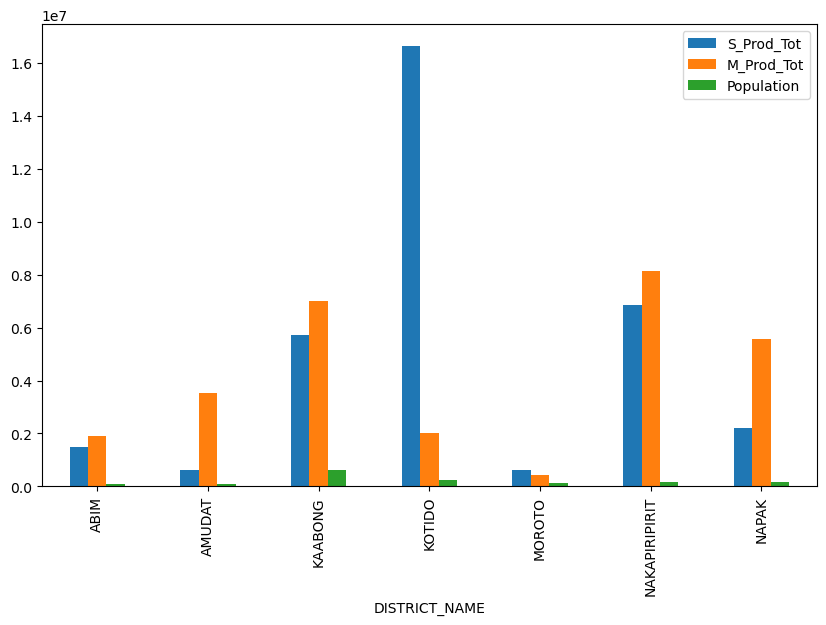

In [50]:
food_security.plot(kind='bar', figsize=(10,6))

###  Insights: Food Production vs Population

The visualization compares total sorghum production, maize production, and population across districts in Karamoja.

#### Key Observations:

- **Kotido** shows extremely high sorghum production compared to other districts, indicating strong agricultural output. However, its population is moderate, suggesting a potential **production surplus**.

- **Kaabong** and **Nakapiripirit** also have relatively high production levels (both maize and sorghum) with moderate population sizes, indicating **good production capacity relative to population**.

- **Napak** and **Amudat** have noticeable production levels, especially in maize, but their populations are also relatively significant, suggesting **balanced but potentially strained resources**.

- **Moroto** has both low production and a moderate population, which may indicate **potential food insecurity risk**.

- **Abim** shows moderate production levels but relatively lower population, suggesting it may be **closer to self-sufficiency or slight surplus**.

#### Conclusion:

There are clear disparities between food production and population across districts.  
Some districts (like Kotido) appear to produce more than needed, while others (like Moroto) may face challenges in meeting food demand.

This highlights the importance of **resource distribution and targeted agricultural support** to improve food security in the region.

## Food Security Analysis (Production per Person)

In this step i calculate total crop production per district and compare it to the population size.

By dividing total production by population i estimate the amount of food available per person in each district.

This helps me understand food availability and identify potential food security issues.

Key insights i can derive include:
- Districts with high production per person (potential food surplus)
- Districts with low production per person (potential food shortage)

In [51]:
# Total production
food_security['Total_Production'] = food_security['S_Prod_Tot'] + food_security['M_Prod_Tot']

# Production per person
food_security['Production_per_Person'] = food_security['Total_Production'] / food_security['Population']

food_security

,S_Prod_Tot,M_Prod_Tot,Population,Total_Production,Production_per_Person
DISTRICT_NAME,,,,,
ABIM,1.472671e+06,1.922133e+06,90384,3.394804e+06,37.559787
AMUDAT,6.103003e+05,3.546469e+06,101790,4.156770e+06,40.836719
KAABONG,5.723091e+06,6.990362e+06,627057,1.271345e+07,20.274796
KOTIDO,1.663429e+07,2.010179e+06,243156,1.864447e+07,76.676972
MOROTO,6.075967e+05,4.221161e+05,127812,1.029713e+06,8.056464
NAKAPIRIPIRIT,6.841727e+06,8.125156e+06,146779,1.496688e+07,101.968835
NAPAK,2.209032e+06,5.587379e+06,167626,7.796411e+06,46.510752


<Axes: xlabel='DISTRICT_NAME'>

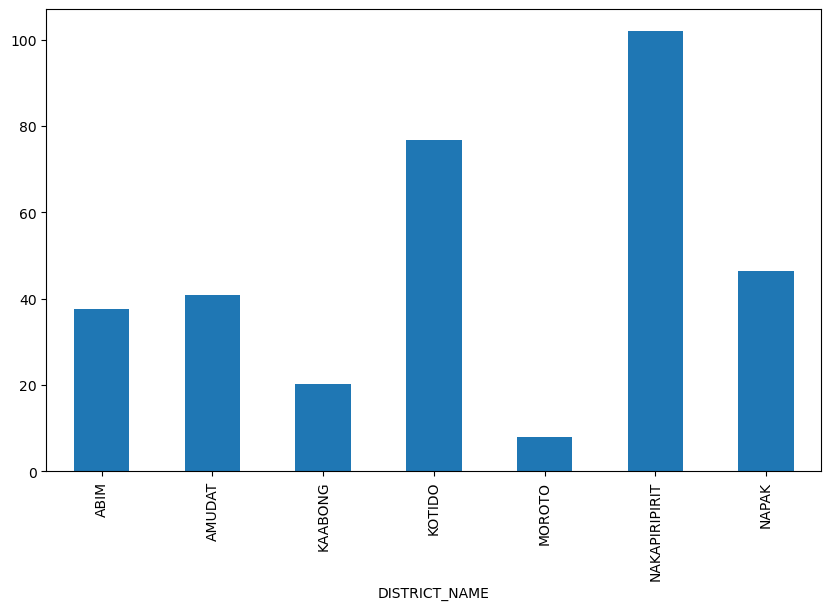

In [52]:
food_security['Production_per_Person'].plot(kind='bar', figsize=(10,6))

### Interpretation

The chart shows differences in food availability per person across districts.

Districts like Nakapiripirit and Kotido have higher production per person, suggesting better food availability.

On the other hand, districts such as Moroto and Kaabong have lower production per person, indicating potential food insecurity.

This suggests unequal distribution of food production relative to population across Karamoja.

## Final Insights and Conclusion

This analysis explored crop production, yield patterns, and population distribution across districts in Karamoja to assess food security.

### Key Findings

- **Maize vs Sorghum Production**
  Maize production is generally higher than sorghum across most districts, indicating a stronger reliance on maize as a staple crop.

- **Yield Differences**
  There is significant variation in crop yields across districts. Some districts such as Kotido and Nakapiripirit show relatively higher yields, while others like Moroto have lower yields.

- **District-Level Production**
  Districts such as Kaabong and Kotido contribute significantly to total crop production, while districts like Moroto produce comparatively less.

- **Population Distribution**
  Population sizes vary widely across districts, with Kaabong having a significantly higher population than others.

- **Food Production vs Population**
  When comparing production with population, some districts produce enough food relative to their population, while others may face pressure due to higher population and lower production.

- **Food Security (Production per Person)**
  Districts like Nakapiripirit and Kotido have higher production per person, suggesting better food availability.
  In contrast, districts such as Moroto and Kaabong show lower production per person, indicating potential food insecurity.

### Overall Conclusion

The analysis reveals unequal distribution of agricultural productivity and food availability across Karamoja. While some districts demonstrate strong production capacity and relatively good food availability, others may be at risk of food shortages.

These findings highlight the need for targeted agricultural interventions, improved farming practices, and resource allocation to support lower-performing districts and enhance overall food security in the region.